# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
1. Target: "close"
1. Timeshift: 40
1. Forecast horizon: 1
1. Remove dayoffs

## Deploy TensorBoard

In [65]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [66]:
import os
import sys
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)

## Helper functions

In [67]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [68]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 5
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"
FEATURE_COLUMNS = ["close"]

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [69]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Hyper Parameters

In [70]:
MAX_EPOCHS = 3000
LEARNING_RATE = 1.0e-06
PATIENCE = 100
BATCH_SIZE = 64

In [71]:
MODEL_PARAMS = {"remove_dayoffs": True}
MODEL_PARAMS

{'remove_dayoffs': True}

## Start

### Get data

In [72]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [73]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [74]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [75]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [76]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "matching_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [77]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.14,28.97,4.74,8.169220e+06,515253831000.0,350040.0,29103040000.0,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.1899999999999,25.363333333333333,4.1066666666666665,1.314382e+07,829832099333.3333,769057.0,45944657000.0,27442.0,5.068024e+07,1852.3333333333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.24,21.756666666666664,3.4733333333333336,1.811842e+07,1144410367666.6665,1188073.0,62786274000.0,28068.0,4.867907e+07,1739.6666666666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.29,18.15,2.84,2.309302e+07,1458988636000.0,1607090.0,79627891000.0,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.71,-19.58,-2.97,1.384280e+07,837466500000.0,226000.0,12099600000.0,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.44499999999999,1.837,7.158068e+08,22272405365000.0,23581058.0,792440247700.0,476711.0,1.233848e+09,2591.3,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.14,36.05,1.98,7.313611e+08,22646206050000.0,23192200.0,777430868000.0,486603.0,1.253004e+09,2575.0,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.62,7.48,0.4,9.667547e+08,31205940310000.0,22413147.0,779573446300.0,598087.0,1.575227e+09,2634.0,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.91,-6.71,-0.36,1.083635e+09,35678521520000.0,62225450.0,1856894317550.0,694266.0,1.862364e+09,2682.0,597096.0,1.892734e+09,3170.0,-3.036983e+07


In [78]:
vn_index_df_close = vn_index_df[[DATE_COLUMN] + FEATURE_COLUMNS]
vn_index_df_close

,date,close
0,2008-03-07,640.140
1,2008-03-08,646.190
2,2008-03-09,652.240
3,2008-03-10,658.290
4,2008-03-11,638.710
...,...,...
6561,2026-02-22,1856.535
6562,2026-02-23,1860.140
6563,2026-02-24,1867.620
6564,2026-02-25,1860.910


In [79]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10276\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2008-03-07,640.140,vn_index
1,2008-03-08,646.190,vn_index
2,2008-03-09,652.240,vn_index
3,2008-03-10,658.290,vn_index
4,2008-03-11,638.710,vn_index
...,...,...,...
6561,2026-02-22,1856.535,vn_index
6562,2026-02-23,1860.140,vn_index
6563,2026-02-24,1867.620,vn_index
6564,2026-02-25,1860.910,vn_index


### Data transformation

In [80]:
vn_index_df_close.shape

(6566, 3)

In [81]:
vn_index_df_close_f1 = vn_index_df_close[~vn_index_df_close["date"].isin(DAYOFFS)]
vn_index_df_close_f1.shape

(4690, 3)

In [82]:
input_df = vn_index_df_close_f1
input_df

,date,close,stock
0,2008-03-07,640.140,vn_index
3,2008-03-10,658.290,vn_index
4,2008-03-11,638.710,vn_index
5,2008-03-12,643.900,vn_index
6,2008-03-13,647.600,vn_index
...,...,...,...
6559,2026-02-20,1849.325,vn_index
6562,2026-02-23,1860.140,vn_index
6563,2026-02-24,1867.620,vn_index
6564,2026-02-25,1860.910,vn_index


### Roll time series

In [83]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:06<00:00,  7.46it/s]


,date,close,stock,id
0,2008-03-07,640.140,vn_index,"(vn_index, 2008-03-14)"
1,2008-03-10,658.290,vn_index,"(vn_index, 2008-03-14)"
2,2008-03-11,638.710,vn_index,"(vn_index, 2008-03-14)"
3,2008-03-12,643.900,vn_index,"(vn_index, 2008-03-14)"
4,2008-03-13,647.600,vn_index,"(vn_index, 2008-03-14)"
...,...,...,...,...
27541,2026-02-20,1849.325,vn_index,"(vn_index, 2026-02-26)"
27542,2026-02-23,1860.140,vn_index,"(vn_index, 2026-02-26)"
27543,2026-02-24,1867.620,vn_index,"(vn_index, 2026-02-26)"
27544,2026-02-25,1860.910,vn_index,"(vn_index, 2026-02-26)"


### Extract features

In [84]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [00:45<00:00,  1.09it/s]


In [85]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2008-03-14                                             1.0   
         2008-03-17                                             1.0   
         2008-03-18                                             1.0   
         2008-03-19                                             1.0   
         2008-03-20                                             1.0   
...                                                             ...   
         2026-02-20                                             1.0   
         2026-02-23                                             1.0   
         2026-02-24                                             1.0   
         2026-02-25                                             1.0   
         2026-02-26                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2008-03-14                       0.0                       0.0   
         2008-03-17                       0.0                       0.0   
         2008-03-18                       0.0                       0.0   
         2008-03-19                       0.0                       0.0   
         2008-03-20                       0.0                       0.0   
...                                       ...                       ...   
         2026-02-20                       0.0                       0.0   
         2026-02-23                       0.0                       0.0   
         2026-02-24                       0.0                       0.0   
         2026-02-25                       0.0                       0.0   
         2026-02-26                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2008-03-14                   0.0           3872.440   
         2008-03-17                   0.0           3848.010   
         2008-03-18                   0.0           3777.980   
         2008-03-19                   0.0           3712.720   
         2008-03-20                   0.0           3633.640   
...                                   ...                ...   
         2026-02-20                   0.0          11034.665   
         2026-02-23                   0.0          11070.715   
         2026-02-24                   0.0          11103.430   
         2026-02-25                   0.0          11125.830   
         2026-02-26                   0.0          11163.355   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2008-03-14       2.499547e+06                  10.084   
         2008-03-17       2.468866e+06                  12.072   
         2008-03-18       2.381571e+06                  13.646   
         2008-03-19       2.302465e+06                  15.570   
         2008-03-20       2.206879e+06                  16.556   
...                                ...                     ...   
         2026-02-20       2.029437e+07                   5.047   
         2026-02-23       2.042719e+07                   5.047   
         2026-02-24       2.054832e+07                   5.822   
         2026-02-25       2.063118e+07                   6.443   
         2026-02-26       2.077084e+07                   9.468   

                     close__mean_change  \
vn_index 2008-03-14               0.732   
         2008-03-17              -8.516   
         2008-03-18             -10.090   
         2008-03-19             -14.090   
         2008-03-20             -16.556   
...                                 ...   
         2026-02-20               5.047   
         2026-02-23               5.047   
         2026-02-24               5.822   
         2026-02-25               3.759   
         2026-02-26               6.784   

                     close__mean_second_derivative_central  close__median  \
vn_index 2008-03-14                              -2.743750       643.8500   
         2008-03-17               

In [86]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,1.0,0.0,0.0,0.0,3872.440,2.499547e+06,10.084,0.732,-2.743750,643.8500,...,1.039721,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-17,1.0,0.0,0.0,0.0,3848.010,2.468866e+06,12.072,-8.516,-1.063750,643.8500,...,1.039721,1.039721,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-18,1.0,0.0,0.0,0.0,3777.980,2.381571e+06,13.646,-10.090,-4.080000,641.2550,...,1.039721,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-19,1.0,0.0,0.0,0.0,3712.720,2.302465e+06,15.570,-14.090,-2.313750,629.7550,...,0.562335,1.039721,1.386294,0.562335,0.636514,0.693147,-0.0,0.0,0.0,0.0
2008-03-20,1.0,0.0,0.0,0.0,3633.640,2.206879e+06,16.556,-16.556,-0.603750,601.9850,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-20,1.0,0.0,0.0,0.0,11034.665,2.029437e+07,5.047,5.047,-0.901250,1840.3125,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2026-02-23,1.0,0.0,0.0,0.0,11070.715,2.042719e+07,5.047,5.047,0.901250,1843.9175,...,0.562335,0.562335,1.039721,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2026-02-24,1.0,0.0,0.0,0.0,11103.430,2.054832e+07,5.822,5.822,0.484375,1847.5225,...,0.562335,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0


### Create forecast target

In [87]:
y = (
    input_df.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2008-03-07,643.800
2008-03-10,615.710
2008-03-11,588.260
2008-03-12,573.450
2008-03-13,564.820
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


In [88]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [89]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,1.0,0.0,0.0,0.0,3872.440,2.499547e+06,10.084,0.732,-2.743750,643.8500,...,1.039721,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-17,1.0,0.0,0.0,0.0,3848.010,2.468866e+06,12.072,-8.516,-1.063750,643.8500,...,1.039721,1.039721,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-18,1.0,0.0,0.0,0.0,3777.980,2.381571e+06,13.646,-10.090,-4.080000,641.2550,...,1.039721,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-19,1.0,0.0,0.0,0.0,3712.720,2.302465e+06,15.570,-14.090,-2.313750,629.7550,...,0.562335,1.039721,1.386294,0.562335,0.636514,0.693147,-0.0,0.0,0.0,0.0
2008-03-20,1.0,0.0,0.0,0.0,3633.640,2.206879e+06,16.556,-16.556,-0.603750,601.9850,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,1.0,0.0,0.0,0.0,10699.370,1.908466e+07,14.304,13.720,1.333750,1776.1700,...,0.562335,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2026-02-16,1.0,0.0,0.0,0.0,10778.785,1.936979e+07,16.333,16.017,1.450625,1805.4700,...,1.039721,1.039721,1.386294,0.562335,0.636514,0.693147,-0.0,0.0,0.0,0.0
2026-02-17,1.0,0.0,0.0,0.0,10862.475,1.967051e+07,16.896,16.896,-4.901875,1819.0900,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0


In [90]:
y

,close
date,
2008-03-14,545.680
2008-03-17,521.070
2008-03-18,496.640
2008-03-19,504.670
2008-03-20,508.750
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


### Create train set

In [91]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [92]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,1.0,0.0,0.0,0.0,3872.44,2.499547e+06,10.084,0.732,-2.74375,643.850,...,1.039721,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-17,1.0,0.0,0.0,0.0,3848.01,2.468866e+06,12.072,-8.516,-1.06375,643.850,...,1.039721,1.039721,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-18,1.0,0.0,0.0,0.0,3777.98,2.381571e+06,13.646,-10.090,-4.08000,641.255,...,1.039721,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-19,1.0,0.0,0.0,0.0,3712.72,2.302465e+06,15.570,-14.090,-2.31375,629.755,...,0.562335,1.039721,1.386294,0.562335,0.636514,0.693147,-0.0,0.0,0.0,0.0
2008-03-20,1.0,0.0,0.0,0.0,3633.64,2.206879e+06,16.556,-16.556,-0.60375,601.985,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,8856.61,1.307380e+07,11.022,2.310,1.30500,1477.500,...,1.039721,1.386294,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2021-12-28,1.0,0.0,0.0,0.0,8873.67,1.312450e+07,11.842,3.130,0.82250,1478.205,...,1.039721,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2021-12-29,1.0,0.0,0.0,0.0,8880.75,1.314548e+07,13.342,1.630,1.51750,1481.745,...,0.562335,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0


In [93]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2008-03-14,545.680
2008-03-17,521.070
2008-03-18,496.640
2008-03-19,504.670
2008-03-20,508.750
...,...
2021-12-27,1518.755
2021-12-28,1525.580
2021-12-29,1522.500


### Select features

In [94]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,"close__cwt_coefficients__coeff_2__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",...,close__cid_ce__normalize_True,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__autocorrelation__lag_1,close__partial_autocorrelation__lag_1,close__count_above_mean,close__has_duplicate_min,close__count_below_mean,close__lempel_ziv_complexity__bins_5,close__fourier_entropy__bins_2,close__approximate_entropy__m_2__r_0.9
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-14,3872.44,1188.617842,696.356113,733.771241,960.292178,1004.223857,438.943232,719.960251,888.776873,731.780668,...,4.308190,0.165873,-0.729336,-0.729336,2.0,0.0,4.0,0.833333,0.562335,0.072736
2008-03-17,3848.01,1185.190369,701.006425,729.322915,955.692706,1004.417978,445.225312,715.710954,885.431364,735.042051,...,2.709904,0.169870,-0.099183,-0.099183,4.0,0.0,2.0,0.833333,0.693147,0.285616
2008-03-18,3777.98,1169.215908,712.490248,716.248618,939.980169,993.559467,451.610937,702.881032,871.227512,729.548248,...,1.878992,0.174036,0.450019,0.450019,4.0,0.0,2.0,0.666667,0.562335,0.089450
2008-03-19,3712.72,1152.101631,715.756412,704.402678,925.319058,983.416963,469.982830,691.064091,858.474964,726.749055,...,1.453553,0.164649,0.671670,0.671670,3.0,0.0,3.0,0.666667,0.562335,0.054115
2008-03-20,3633.64,1126.890589,698.145623,689.664004,906.080597,964.139388,473.899152,676.684628,840.937413,715.013885,...,1.325264,0.156805,0.699162,0.699162,3.0,0.0,3.0,0.666667,0.562335,0.182597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,8856.61,2715.356671,1582.988331,1678.272889,2195.313801,2293.374280,1000.131083,1646.169247,2032.173737,1670.752639,...,3.287347,0.162365,-0.063269,-0.063269,5.0,0.0,1.0,0.666667,0.693147,0.054115
2021-12-28,8873.67,2718.225933,1572.348664,1681.094485,2198.852362,2293.867464,988.940525,1649.462533,2034.783848,1668.970696,...,2.700181,0.166225,0.297577,0.297577,2.0,0.0,4.0,0.666667,0.562335,0.223144
2021-12-29,8880.75,2721.712159,1575.651919,1682.305658,2200.498101,2295.842864,979.705138,1650.504890,2036.503753,1669.300717,...,2.732197,0.168633,0.426826,0.426826,3.0,0.0,3.0,0.833333,0.562335,0.054115


### Create validation set

In [95]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [96]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,"close__cwt_coefficients__coeff_2__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",...,close__cid_ce__normalize_True,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__autocorrelation__lag_1,close__partial_autocorrelation__lag_1,close__count_above_mean,close__has_duplicate_min,close__count_below_mean,close__lempel_ziv_complexity__bins_5,close__fourier_entropy__bins_2,close__approximate_entropy__m_2__r_0.9
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,8972.095,2748.067192,1593.042477,1699.813495,2222.991683,2318.676146,1000.716655,1667.512932,2057.138449,1686.691379,...,2.280945,0.164573,0.224941,0.224941,2.0,0.0,4.0,0.666667,0.562335,0.285616
2022-01-04,9008.795,2757.214378,1587.277984,1706.523368,2231.189979,2324.241984,990.503630,1674.196222,2064.456604,1688.546349,...,1.705161,0.165943,0.643423,0.643423,2.0,0.0,4.0,0.666667,0.562335,0.089450
2022-01-05,9036.905,2767.224485,1596.250582,1711.628369,2238.106267,2331.391586,984.230001,1679.282185,2070.614424,1692.158002,...,1.493488,0.169447,0.734760,0.734760,3.0,0.0,3.0,0.666667,0.562335,0.331374
2022-01-06,9079.655,2782.113417,1614.252734,1719.817101,2249.119076,2344.571565,993.742169,1687.137161,2080.917550,1702.291658,...,1.645365,0.169370,0.529716,0.529716,4.0,0.0,2.0,0.833333,0.693147,0.089450
2022-01-07,9122.165,2797.112113,1630.033955,1728.179212,2260.516199,2359.405814,1011.731674,1695.280607,2091.873785,1715.418704,...,2.165522,0.167128,0.224251,0.224251,4.0,0.0,2.0,0.666667,0.693147,0.053140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-25,6612.090,2025.628704,1175.408865,1252.580757,1638.159297,1708.430664,732.578350,1228.777430,1515.835546,1241.952512,...,2.001764,0.166783,0.254911,0.254911,3.0,0.0,3.0,0.666667,0.562335,0.010963
2023-12-26,6642.460,2034.140508,1176.388781,1258.349781,1645.359904,1714.983628,732.851533,1234.399754,1522.472308,1246.171190,...,1.697142,0.165447,0.524246,0.524246,2.0,0.0,4.0,0.666667,0.562335,0.089450
2023-12-27,6668.150,2042.550576,1180.891103,1263.087735,1651.875794,1722.001729,732.987083,1239.253517,1528.404407,1251.060839,...,1.636149,0.168550,0.678270,0.678270,3.0,0.0,3.0,0.666667,0.562335,0.331374


In [97]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-03,1503.7100
2022-01-04,1492.3100
2022-01-05,1510.5100
2022-01-06,1496.0500
2022-01-07,1496.0200
...,...
2023-12-25,1131.2725
2023-12-26,1131.7200
2023-12-27,1144.1700


### Create test set

In [98]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2026-02-26')

In [99]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,"close__cwt_coefficients__coeff_2__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_2__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",...,close__cid_ce__normalize_True,close__energy_ratio_by_chunks__num_segments_10__segment_focus_3,close__autocorrelation__lag_1,close__partial_autocorrelation__lag_1,close__count_above_mean,close__has_duplicate_min,close__count_below_mean,close__lempel_ziv_complexity__bins_5,close__fourier_entropy__bins_2,close__approximate_entropy__m_2__r_0.9
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,6752.0325,2070.089175,1203.984730,1279.147837,1673.360514,1746.818753,751.177164,1254.957609,1548.580220,1270.727200,...,1.704493,0.167729,0.530007,0.530007,3.0,0.0,3.0,0.666667,0.562335,0.054115
2024-01-02,6766.0925,2074.910347,1208.417651,1281.866582,1676.994824,1751.272234,754.336044,1257.553760,1552.105267,1274.382207,...,1.773684,0.167330,0.604099,0.604099,4.0,0.0,2.0,0.666667,0.562335,0.089450
2024-01-03,6788.0125,2080.307379,1209.565445,1285.969141,1682.043655,1755.167779,755.383755,1261.551085,1556.541511,1276.557695,...,2.181323,0.166642,0.142446,0.142446,2.0,0.0,4.0,0.833333,0.562335,0.089450
2024-01-04,6816.7425,2087.909501,1208.764261,1291.409779,1688.771384,1760.974030,755.292582,1266.852620,1562.753682,1280.268165,...,1.712936,0.165368,0.519858,0.519858,2.0,0.0,4.0,0.666667,0.562335,0.089450
2024-01-05,6842.4925,2095.403328,1210.446051,1296.123354,1694.927144,1766.445650,752.304217,1271.621659,1568.217457,1283.273665,...,1.477052,0.167753,0.664660,0.664660,3.0,0.0,3.0,0.666667,0.562335,0.331374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,10699.3700,3270.727869,1868.830215,2026.183876,2648.154359,2752.448028,1150.700193,1988.032997,2449.195467,1994.642822,...,1.599117,0.169176,0.664819,0.664819,3.0,0.0,3.0,0.666667,0.562335,0.331374
2026-02-16,10778.7850,3296.460425,1890.601526,2041.171982,2667.563815,2772.786745,1151.268856,2002.313095,2467.252486,2007.917673,...,1.521495,0.169900,0.651882,0.651882,4.0,0.0,2.0,0.666667,0.562335,0.089450
2026-02-17,10862.4750,3325.663596,1922.435335,2057.275898,2689.314843,2798.921065,1172.465029,2018.064771,2487.448276,2028.354152,...,1.691103,0.169152,0.433272,0.433272,4.0,0.0,2.0,0.833333,0.693147,0.010963


In [100]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1160.190
2024-01-02,1158.590
2024-01-03,1161.540
2024-01-04,1162.220
2024-01-05,1154.700
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


### Validate before scaling

In [101]:
import numpy as np


def get_bad_columns(
    df: pd.DataFrame, variance_threshold=1e-6, range_threshold=1e6
) -> np.ndarray:
    """
    Returns indices of columns that are:
    - NaN anywhere
    - Inf anywhere
    - Near-constant (variance below threshold) → causes scaler explosion
    - Extreme range (max - min above threshold) → causes scaler explosion
    """
    col_values = df.values.astype(np.float64)

    has_nan = np.isnan(col_values).any(axis=0)
    has_inf = np.isinf(col_values).any(axis=0)

    col_range = col_values.max(axis=0) - col_values.min(axis=0)
    near_constant = col_range < variance_threshold
    extreme_range = col_range > range_threshold

    bad_mask = has_nan | has_inf | near_constant | extreme_range
    return np.where(bad_mask)[0]


# --- Apply BEFORE scaling ---

# Detect from TRAIN only (no val/test data influence)
bad_cols = get_bad_columns(X_train_selected)
good_cols = np.setdiff1d(np.arange(X_train_selected.shape[1]), bad_cols)

print(f"Removed {len(bad_cols)} bad columns, keeping {len(good_cols)}")

# Apply the same good_cols mask to all splits
X_train_clean = X_train_selected.iloc[:, good_cols]
X_val_clean = X_validation_selected.iloc[:, good_cols]
X_test_clean = X_test_selected.iloc[:, good_cols]

# Sanity check after filtering, before scaling
assert not np.isnan(
    X_train_clean.values
).any(), "NaN still present in X_train after filtering"
assert not np.isinf(
    X_train_clean.values
).any(), "Inf still present in X_train after filtering"
assert not np.isnan(
    X_val_clean.values
).any(), "NaN still present in X_val after filtering"
assert not np.isinf(
    X_val_clean.values
).any(), "Inf still present in X_val after filtering"

# Update INPUT_SIZE after filtering
INPUT_SIZE = X_train_clean.shape[1]
print(f"INPUT_SIZE after filtering: {INPUT_SIZE}")

Removed 5 bad columns, keeping 149
INPUT_SIZE after filtering: 149


### Create scaler

In [102]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train_clean)
y_train_scaled = y_scaler.fit_transform(y_train)

X_validation_scaled = X_scaler.transform(X_val_clean)
y_validation_scaled = y_scaler.transform(y_validation)

X_test_scaled = X_scaler.transform(X_test_clean)
y_test_scaled = y_scaler.transform(y_test)

In [103]:
print(
    "X_train scaled range:", X_train_scaled.min(), "→", X_train_scaled.max()
)  # [0, 1]
print(
    "X_val   scaled range:", X_validation_scaled.min(), "→", X_validation_scaled.max()
)  # ~[0, 1]
print(
    "y_train scaled range:", y_train_scaled.min(), "→", y_train_scaled.max()
)  # ~[-3, 3] for StandardScaler
print(
    "y_val   scaled range:", y_validation_scaled.min(), "→", y_validation_scaled.max()
)  # can exceed this, that's fine

X_train scaled range: 0.0 → 1.0000000000000004
X_val   scaled range: -0.2540287137415751 → 1.4477149496514305
y_train scaled range: 0.0 → 1.0
y_val   scaled range: 0.52309619742164 → 0.9970071225842376


### Validate shape

In [104]:
X_train_scaled.shape

(3601, 149)

In [105]:
y_train_scaled.shape

(3601, 1)

In [106]:
X_validation_scaled.shape

(520, 149)

In [107]:
y_validation_scaled.shape

(520, 1)

In [108]:
X_test_scaled.shape

(559, 149)

In [109]:
y_test_scaled.shape

(559, 1)

### Create dataloader

In [110]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [111]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaled, dtype=torch.float32),
    torch.tensor(y_validation_scaled, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [112]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [113]:
config_dto = ConfigDto(
    # Data
    notebook_name=NOTEBOOK_NAME,
    base_features=FEATURE_COLUMNS,
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    max_lookback_window_size=MAX_TIMESHIFT,
    min_lookback_window_size=MIN_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params=MODEL_PARAMS,
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [114]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * (self.input_size // 4), 64), nn.ReLU(), nn.Linear(64, 1)
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [115]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

Seed set to 18


### Train model

In [116]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [117]:
import torch
from lightning.pytorch.loggers import TensorBoardLogger

torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

# logger = TensorBoardLogger(
#     "D:/GIT/master-thesis/src/model/lightning_logs", name="", version=3
# )
# path_to_checkpoint = "D:/GIT/master-thesis/src/model/lightning_logs/version_3/checkpoints/epoch=4960-step=783838.ckpt"

logger = None
path_to_checkpoint = None

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop_callback],
    logger=logger,
)

trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=validation_dataloader,
    ckpt_path=path_to_checkpoint,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | conv | Sequential | 6.3 K  | train | 0    
1 | fc   | Sequential | 151 K  | train | 0    
----------------------------------------------------
158 K     Trainable params
0         Non-trainable params
158 K     Total params
0.632     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 316: 100%|██████████| 57/57 [00:00<00:00, 74.54it/s, v_num=51, val_loss=0.00076]  


In [118]:
y_test

,close
date,
2024-01-01,1160.190
2024-01-02,1158.590
2024-01-03,1161.540
2024-01-04,1162.220
2024-01-05,1154.700
...,...
2026-02-13,1849.325
2026-02-16,1860.140
2026-02-17,1867.620


In [119]:
y_test.shape

(559, 1)

In [120]:
y_pred_tensor = model(torch.tensor(X_test_scaled, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

,predict
last_date,
2024-01-01,1130.929443
2024-01-02,1132.058472
2024-01-03,1148.487305
2024-01-04,1153.189941
2024-01-05,1159.243530
...,...
2026-02-13,1774.922241
2026-02-16,1799.077515
2026-02-17,1827.453613


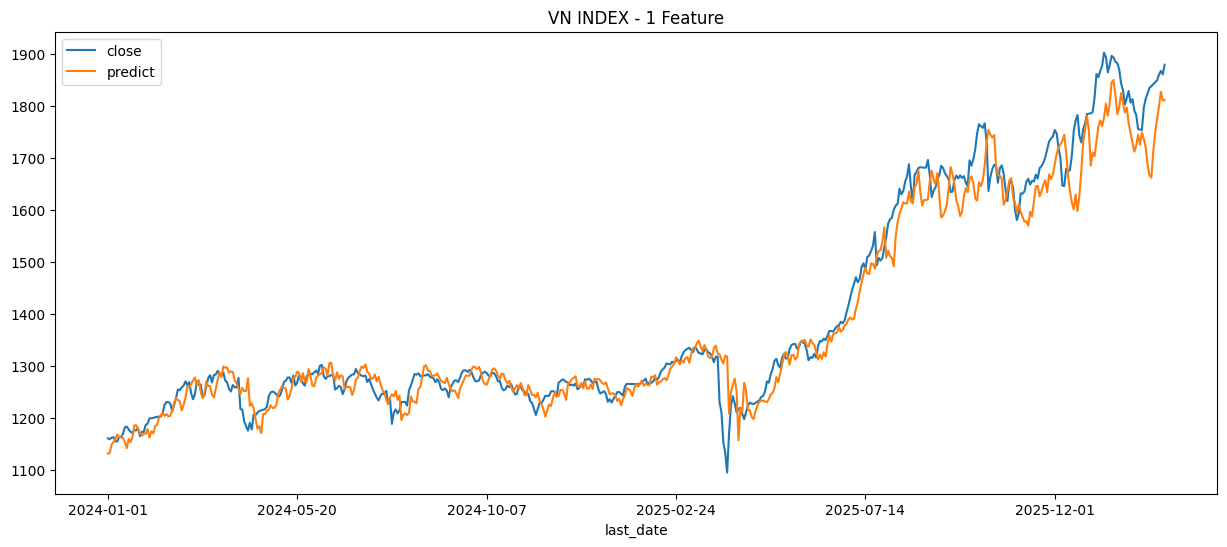

In [121]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [122]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [123]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.where(y_true == 0, 0, np.abs((y_true - y_pred) / y_true))) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

# 4️⃣ SMAPE (Symmetric MAPE)
denom = np.abs(y_true) + np.abs(y_pred)
smape = np.mean(np.where(denom == 0, 0, 2 * np.abs(y_pred - y_true) / denom)) * 100

# 5️⃣ WAPE (Weighted Absolute Percentage Error)
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

# 6️⃣ R² (Coefficient of Determination)
r2 = r2_score(y_true, y_pred)

# 7️⃣ Adjusted R²
# Requires number of samples (n) and features (p)
n = len(y_true)
p = X_test_scaled.shape[1]  # make sure X_test exists

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------
# Print results
# -----------------------

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")
print(f"SMAPE: {smape:.4f} %")
print(f"WAPE: {wape:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MSE: 1897.0892
MAPE: 2.0427 %
RMSSE: 2.8522
SMAPE: 2.0537 %
WAPE: 0.0215
R2: 0.9568
Adjusted R2: 0.9411


### Predict

In [124]:
# Get last row and keep 2D shape
last_row = X_test_scaled[-1:]
last_row.shape

(1, 149)

In [125]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

1811.8119

### Save data

In [126]:
import os
import sys
import pickle
import ipynbname
import json
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)


# -----------------------
# Save metrics to JSON
# -----------------------
result_path = os.path.join(result_folder, "result.json")

results = {
    "MSE": mse,
    "MAPE": mape,
    "RMSSE": rmsse,
    "SMAPE": smape,
    "WAPE": wape,
    "R2": r2,
    "Adjusted_R2": adj_r2,
}

with open(result_path, "w") as f:
    json.dump(results, f, indent=4)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

Saved results to: lightning_logs\version_51


In [127]:
from win11toast import toast
import ipynbname

NB_NAME = ipynbname.name()

# Simple notification
toast("Completed training", f"Model '{NB_NAME}' trained successfully.")

<Future pending>